# How well do jobs and skills pay for Data Analysts?

#### Methodology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

## Import Libraries and Data

In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Usuario\.conda\envs\da_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Salary Distribution by Job Title

Filter our data to only include salary values from the United States.

In [ ]:
df_US = df[(df["job_country"] == "United States")].dropna(subset=["salary_year_avg"])

Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [12]:
job_titles = df_US["job_title_short"].value_counts().index[:6].tolist()

df_US_top6 = df_US[df_US["job_title_short"].isin(job_titles)]

job_order = df_US_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index

job_order

Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='str', name='job_title_short')

Plot the top 6 job titles salary distributions using a box plot.

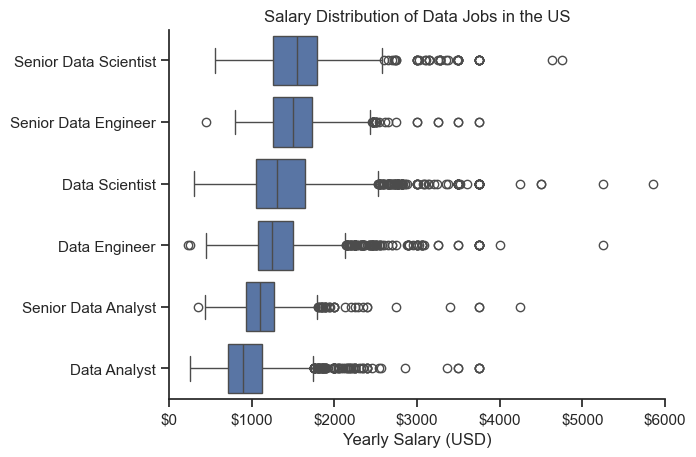

In [ ]:
sns.boxplot(data=df_US_top6, x="salary_year_avg", y="job_title_short", order=job_order)
sns.set_theme(style="ticks")
sns.despine()

plt.title("Salary Distribution of Data Jobs in the US")
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("")
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K")
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

In [19]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

df_DA_US = df_DA_US.dropna(subset=["salary_year_avg"])

df_DA_US = df_DA_US.explode("job_skills")

## Determine The Highest Paid Skills and Most Demanded Skills

Highest Paid Skills

In [ ]:
df_DA_top_pay = df_DA_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="median", ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

Most Demanded Skills

In [ ]:
df_DA_skills = df_DA_US.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="count", ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by="median", ascending=False)

df_DA_skills

Creates two horizontal bar charts: 
1. Displays the highest paid skills 
2. Shows the most in demand skills 

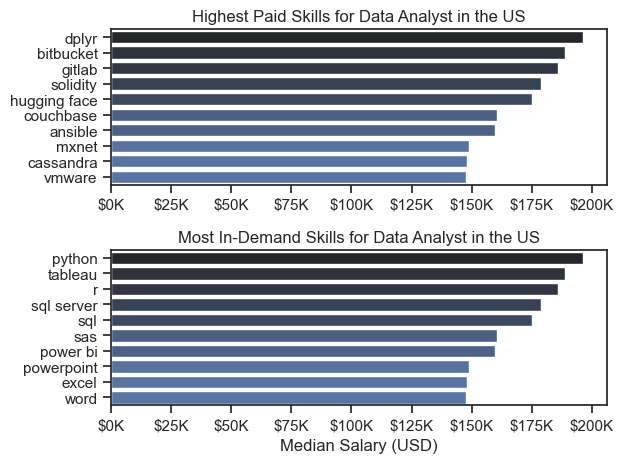

In [ ]:
fig, ax = plt.subplots(2,1)

sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_top_pay.index, hue="median", ax=ax[0], palette="dark:b_r")
ax[0].legend().remove()
ax[0].set_title("Highest Paid Skills for Data Analyst in the US")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_skills.index, hue="median", ax=ax[1], palette="dark:b_r")
ax[1].legend().remove()
ax[1].set_title("Most In-Demand Skills for Data Analyst in the US")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

sns.set_theme(style="ticks")
plt.tight_layout()
plt.show()